# Supp Fig 8 — FP/FN calls localize to distinct clusters

Reproduces **SuppFig8** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Supp Fig 8 — integrated UMAP density 4 groups (cell 22)
**🟢 light (reads caches)** · source: `umap_FN_FP_clusters.ipynb cell 22`

In [ ]:
# 1) 統合 UMAP に 4 群 (TP/FN/FP/TN) の embedding density を表示
try:
    rsc.tl.embedding_density(adata_int, basis='umap', groupby='group')
    backend = 'rsc'
except (AttributeError, NotImplementedError, TypeError):
    sc.tl.embedding_density(adata_int, basis='umap', groupby='group')
    backend = 'scanpy'
print(f'embedding_density backend: {backend}')

umap_int = adata_int.obsm['X_umap']
groups_int = adata_int.obs['group'].astype(str).values
dens_int = adata_int.obs['umap_density_group'].astype(float).values

fig, axes = plt.subplots(1, 4, figsize=(22, 5.6))
for ax, g in zip(axes, GROUP_ORDER):
    in_g = groups_int == g
    ax.scatter(umap_int[~in_g, 0], umap_int[~in_g, 1], c='lightgray', s=2,
               alpha=0.25, edgecolors='none')
    if in_g.any():
        sc_ = ax.scatter(umap_int[in_g, 0], umap_int[in_g, 1], c=dens_int[in_g], s=5,
                          cmap='YlOrRd', alpha=0.85, edgecolors='none',
                          vmin=0, vmax=1)
        cbar = fig.colorbar(sc_, ax=ax, fraction=0.04, pad=0.02, shrink=0.7)
        cbar.set_label('density (within group)', fontsize=8)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'{g}  (n={int(in_g.sum()):,})',
                 fontsize=13, fontweight='bold', color=GROUP_PALETTE[g])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('UMAP1', fontsize=9)
    if g == GROUP_ORDER[0]: ax.set_ylabel('UMAP2', fontsize=9)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)
fig.suptitle('Integrated UMAP — embedding density by group  '
              '(within-group normalized)',
              fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'umap_int_density_4groups.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "umap_int_density_4groups"}.{{png,pdf}}')
plt.show()

### Supp Fig 8 — embedding density integrated (cell 55)
**🟢 light (reads caches)** · source: `umap_FN_FP_clusters.ipynb cell 55`

In [ ]:
# Compute embedding density per group on the integrated UMAP
try:
    rsc.tl.embedding_density(adata_int, basis='umap', groupby='group')
    print('embedding_density via rapids-singlecell (GPU)')
except (AttributeError, NotImplementedError, TypeError) as e:
    print(f'  rsc.tl.embedding_density unavailable ({type(e).__name__}); '
          'falling back to scanpy CPU')
    sc.tl.embedding_density(adata_int, basis='umap', groupby='group')

# Custom 4-panel plot — one per group, density-colored within group
umap = adata_int.obsm['X_umap']
groups = adata_int.obs['group'].astype(str).values
densities = adata_int.obs['umap_density_group'].astype(float).values

fig, axes = plt.subplots(1, 4, figsize=(22, 5.6))
for ax, g in zip(axes, GROUP_ORDER):
    in_g = groups == g
    # Background: other groups in light gray for spatial reference
    ax.scatter(umap[~in_g, 0], umap[~in_g, 1], c='lightgray', s=2,
               alpha=0.25, edgecolors='none')
    # Foreground: cells in group, colored by within-group density
    if in_g.any():
        d = densities[in_g]
        sc_ = ax.scatter(umap[in_g, 0], umap[in_g, 1], c=d, s=5,
                          cmap='YlOrRd', alpha=0.85, edgecolors='none',
                          vmin=0, vmax=1)
        cbar = fig.colorbar(sc_, ax=ax, fraction=0.04, pad=0.02, shrink=0.7)
        cbar.set_label('density (within group)', fontsize=8)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'{g}  (n={int(in_g.sum()):,})',
                 fontsize=13, fontweight='bold',
                 color=GROUP_PALETTE[g])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('UMAP1', fontsize=9)
    if g == GROUP_ORDER[0]:
        ax.set_ylabel('UMAP2', fontsize=9)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)

fig.suptitle(f'Integrated UMAP — embedding density by group  '
             f'(n={adata_int.n_obs:,} cells, normalized within each group)',
              fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'embedding_density_integrated.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "embedding_density_integrated"}.{{png,pdf}}')
plt.show()

### Supp Fig 8 — density split by SPATNIC class (cell 57)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 57`

In [ ]:
# Split into SPATNIC=Tumor (TP+FP) and SPATNIC=Normal (TN+FN) subsets
mask_T = adata_int.obs['group'].isin(['TP', 'FP'])
mask_N = adata_int.obs['group'].isin(['TN', 'FN'])
adata_T = adata_int[mask_T].copy()
adata_N = adata_int[mask_N].copy()
print(f'SPATNIC=Tumor  (TP+FP): {adata_T.n_obs:,} cells')
print(f'SPATNIC=Normal (TN+FN): {adata_N.n_obs:,} cells')

# Compute embedding density within each subset (normalized within each group of the subset)
def _density(a, label):
    try:
        rsc.tl.embedding_density(a, basis='umap', groupby='group')
        backend = 'rsc'
    except (AttributeError, NotImplementedError, TypeError):
        sc.tl.embedding_density(a, basis='umap', groupby='group')
        backend = 'scanpy'
    print(f'  density ({label}): {backend}')

_density(adata_T, 'SPATNIC=Tumor')
_density(adata_N, 'SPATNIC=Normal')

# 2 row × 2 col: row = SPATNIC class, col = original-label-derived group
umap_full = adata_int.obsm['X_umap']

panel_cfg = [
    (0, 0, adata_T, 'TP', 'SPATNIC=Tumor pool → TP density  (orig=Tumor & SPATNIC=Tumor)'),
    (0, 1, adata_T, 'FP', 'SPATNIC=Tumor pool → FP density  (orig=Normal, SPATNIC=Tumor)'),
    (1, 0, adata_N, 'TN', 'SPATNIC=Normal pool → TN density  (orig=Normal & SPATNIC=Normal)'),
    (1, 1, adata_N, 'FN', 'SPATNIC=Normal pool → FN density  (orig=Tumor, SPATNIC=Normal)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for r, c, a, g, title in panel_cfg:
    ax = axes[r, c]
    # Background: entire integrated UMAP for spatial reference
    ax.scatter(umap_full[:, 0], umap_full[:, 1], c='lightgray', s=2,
               alpha=0.20, edgecolors='none')
    # Foreground: this group's cells from the subset, colored by within-group density
    in_g = a.obs['group'].astype(str).values == g
    if in_g.any():
        umap_g = a.obsm['X_umap'][in_g]
        dens_g = a.obs['umap_density_group'].astype(float).values[in_g]
        sc_ = ax.scatter(umap_g[:, 0], umap_g[:, 1], c=dens_g, s=5,
                          cmap='YlOrRd', alpha=0.85, edgecolors='none',
                          vmin=0, vmax=1)
        cbar = fig.colorbar(sc_, ax=ax, fraction=0.04, pad=0.02, shrink=0.7)
        cbar.set_label('density (within subset)', fontsize=8)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'{title}\n(n={int(in_g.sum()):,})',
                 fontsize=11, fontweight='bold', color=GROUP_PALETTE[g])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('UMAP1', fontsize=9)
    if c == 0: ax.set_ylabel('UMAP2', fontsize=9)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)

fig.suptitle('Integrated UMAP — density split by SPATNIC prediction class\n'
             f'(top: SPATNIC=Tumor pool n={int(mask_T.sum()):,};  '
             f'bottom: SPATNIC=Normal pool n={int(mask_N.sum()):,})',
              fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'embedding_density_split_by_spatnic.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "embedding_density_split_by_spatnic"}.{{png,pdf}}')
plt.show()

### Supp Fig 8 — per-SPATNIC-pool UMAP + density (cell 59)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 59`

In [ ]:
# Process each SPATNIC pool independently (own PCA/Harmony/UMAP/leiden + density)
POOL_CFG = [
    ('Tumor',  ['TP', 'FP'], 'pool_tumor_harmony.h5ad'),
    ('Normal', ['TN', 'FN'], 'pool_normal_harmony.h5ad'),
]

def process_pool(pool_name, groups_inc, cache_name):
    cache_path = ADATA_CACHE / cache_name
    if cache_path.exists():
        print(f'  pool={pool_name}: cache hit → {cache_path.name}', flush=True)
        return ad.read_h5ad(cache_path)
    t0 = time.time()
    mask = adata_int.obs['group'].isin(groups_inc).values
    a = adata_int[mask].copy()
    # Restore raw counts (3000 HVG only, from layer)
    a.X = a.layers['counts'].copy()
    if a.X.dtype.kind in ('i', 'u'):
        a.X = a.X.astype(np.float32)

    _to_gpu(a)
    print(f'  pool={pool_name}: GPU pipeline (n={a.n_obs:,}) …', flush=True)
    rsc.pp.normalize_total(a, target_sum=1e4)
    rsc.pp.log1p(a)
    rsc.pp.scale(a, max_value=10)
    rsc.pp.pca(a, n_comps=N_PCS)
    rsc.pp.harmony_integrate(a, key='sample_full')
    rsc.pp.neighbors(a, use_rep='X_pca_harmony', n_neighbors=N_NEIGHBORS)
    rsc.tl.umap(a)
    rsc.tl.leiden(a, resolution=LEIDEN_RES, key_added='leiden')
    _to_cpu(a)

    # embedding density (CPU is reliable; pool size is small)
    try:
        rsc.tl.embedding_density(a, basis='umap', groupby='group')
        backend = 'rsc'
    except (AttributeError, NotImplementedError, TypeError):
        sc.tl.embedding_density(a, basis='umap', groupby='group')
        backend = 'scanpy'

    print(f'    {pool_name}: {time.time()-t0:.1f}s, '
          f'leiden={a.obs["leiden"].nunique()}, density={backend}')
    a.write(cache_path)
    return a

pools = {}
for pool_name, groups, cache in POOL_CFG:
    pools[pool_name] = process_pool(pool_name, groups, cache)

# ── 2 row × 3 col plot: per pool (overview + 2 density panels) ──
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for r, (pool_name, groups, _) in enumerate(POOL_CFG):
    a = pools[pool_name]
    umap = a.obsm['X_umap']
    g_arr = a.obs['group'].astype(str).values
    dens = a.obs['umap_density_group'].astype(float).values

    # Col 0: 2-color overview (TP/FP or TN/FN)
    ax = axes[r, 0]
    # rare group last → on top
    rare_first = sorted(groups, key=lambda g: -(g_arr == g).sum())
    for g in rare_first:
        sel = g_arr == g
        ax.scatter(umap[sel, 0], umap[sel, 1], c=GROUP_PALETTE[g], s=4,
                   alpha=0.8, edgecolors='none',
                   label=f'{g} (n={int(sel.sum()):,})')
    ax.legend(loc='best', fontsize=11, markerscale=3, frameon=True, framealpha=0.9)
    ax.set_title(f'SPATNIC={pool_name} pool — by group  (n={a.n_obs:,})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ('top','right'): ax.spines[sp].set_visible(False)

    # Cols 1-2: density per group
    for c, g in enumerate(groups, start=1):
        ax = axes[r, c]
        # background: ALL pool cells in light gray
        ax.scatter(umap[:, 0], umap[:, 1], c='lightgray', s=2,
                   alpha=0.25, edgecolors='none')
        # foreground: this group, colored by density (within-group normalized)
        in_g = g_arr == g
        if in_g.any():
            sc_ = ax.scatter(umap[in_g, 0], umap[in_g, 1], c=dens[in_g], s=5,
                              cmap='YlOrRd', alpha=0.85, edgecolors='none',
                              vmin=0, vmax=1)
            cbar = fig.colorbar(sc_, ax=ax, fraction=0.04, pad=0.02, shrink=0.7)
            cbar.set_label('density (within group)', fontsize=8)
            cbar.ax.tick_params(labelsize=7)
        ax.set_title(f'{g} density  (n={int(in_g.sum()):,})',
                     fontsize=12, fontweight='bold', color=GROUP_PALETTE[g])
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ('top','right'): ax.spines[sp].set_visible(False)

fig.suptitle('Per-SPATNIC-pool independent UMAP & embedding density',
              fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'embedding_density_per_pool_umap.{ext}',
                dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "embedding_density_per_pool_umap"}.{{png,pdf}}')
plt.show()

### Supp Fig 8 — FP/FN-specific clusters per pool + DE (cell 63)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 63`

In [ ]:
import gseapy as gp
from scipy import sparse as sp_

PADJ_THRESH = 0.05
LFC_THRESH  = 1.0
HIGHLIGHT_GENES_2 = {'DUOX1', 'DUOX2', 'DUOXA1', 'DUOXA2'}
PATHWAY_LIBRARIES_2 = ['MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'Reactome_2022']

# ── Identify specific clusters ──
def identify_specific(adata_pool, target_group, min_enr=3.0, min_target_cells=30):
    g  = adata_pool.obs['group'].astype(str).values
    lid = adata_pool.obs['leiden'].astype(str).values
    pool_freq = (g == target_group).sum() / len(g)
    rows = []
    for c in sorted(set(lid), key=int):
        in_c = lid == c
        n_total = int(in_c.sum())
        n_t = int(((g == target_group) & in_c).sum())
        frac = n_t / n_total if n_total > 0 else 0.0
        enr = frac / pool_freq if pool_freq > 0 else 0.0
        rows.append({'cluster': c, 'n_cluster': n_total, f'n_{target_group}': n_t,
                      f'frac_{target_group}': frac, 'enrichment': enr,
                      'is_specific': enr >= min_enr and n_t >= min_target_cells})
    return pd.DataFrame(rows)

fp_stats = identify_specific(pools['Tumor'],  'FP')
fn_stats = identify_specific(pools['Normal'], 'FN')
fp_stats.to_csv(OUT_DIR / 'cluster_enrichment_FP.csv', index=False)
fn_stats.to_csv(OUT_DIR / 'cluster_enrichment_FN.csv', index=False)
fp_clusters = fp_stats.loc[fp_stats['is_specific'], 'cluster'].tolist()
fn_clusters = fn_stats.loc[fn_stats['is_specific'], 'cluster'].tolist()

print('FP enrichment by cluster (Tumor pool, top 8 by enrichment):')
print(fp_stats.sort_values('enrichment', ascending=False).head(8).to_string(index=False))
print(f'\nFP-specific clusters: {fp_clusters}\n')
print('FN enrichment by cluster (Normal pool, top 8):')
print(fn_stats.sort_values('enrichment', ascending=False).head(8).to_string(index=False))
print(f'\nFN-specific clusters: {fn_clusters}')

# ── Highlight specific clusters on pool UMAP ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (pool_name, _, _), spec_list, target in zip(
        axes, POOL_CFG, [fp_clusters, fn_clusters], ['FP', 'FN']):
    a = pools[pool_name]
    umap = a.obsm['X_umap']
    leiden = a.obs['leiden'].astype(str).values
    in_spec = np.isin(leiden, spec_list)
    ax.scatter(umap[~in_spec, 0], umap[~in_spec, 1], c='lightgray', s=2,
               alpha=0.3, edgecolors='none')
    if in_spec.any():
        ax.scatter(umap[in_spec, 0], umap[in_spec, 1], c=GROUP_PALETTE[target], s=5,
                   alpha=0.85, edgecolors='black', linewidths=0.1,
                   label=f'{target}-specific: clusters {",".join(spec_list)}\nn={int(in_spec.sum()):,}')
        ax.legend(loc='best', fontsize=10, frameon=True, framealpha=0.9)
    else:
        ax.text(0.5, 0.5, f'(no {target}-specific cluster\nenr>=3, n>=30)',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
    ax.set_title(f'SPATNIC={pool_name} pool — {target}-specific clusters',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ('top','right'): ax.spines[sp].set_visible(False)
fig.suptitle('FP / FN specific clusters  (enrichment >= 3x baseline)',
              fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'specific_clusters_per_pool.{ext}',
                dpi=170, bbox_inches='tight')
print(f'\nSaved: {OUT_DIR / "specific_clusters_per_pool"}.{{png,pdf}}')
plt.show()

# ── DE: specific clusters vs rest of pool ──
def cluster_marker_de(adata_pool, specific_clusters, target):
    if not specific_clusters:
        print(f'  {target}: no specific cluster; DE skipped'); return pd.DataFrame()
    a = adata_pool.copy()
    a.X = a.layers['counts'].copy()
    if a.X.dtype.kind in ('i', 'u'):
        a.X = a.X.astype(np.float32)
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    leiden = a.obs['leiden'].astype(str).values
    a.obs['de_class'] = pd.Categorical(
        np.where(np.isin(leiden, specific_clusters), 'specific', 'other'),
        categories=['other', 'specific'])
    sc.tl.rank_genes_groups(a, 'de_class', groups=['specific'], reference='other',
                             method='wilcoxon', use_raw=False)
    res = a.uns['rank_genes_groups']
    df = pd.DataFrame({
        'gene':   [r[0] for r in res['names']],
        'log2FC': [r[0] for r in res['logfoldchanges']],
        'p':      [r[0] for r in res['pvals']],
        'p_adj':  [r[0] for r in res['pvals_adj']],
    })
    df['target'] = target
    return df

print('\nDE FP-specific vs rest of Tumor pool …', flush=True)
de_fp = cluster_marker_de(pools['Tumor'],  fp_clusters, 'FP')
print(f'  → {len(de_fp)} genes')
print('DE FN-specific vs rest of Normal pool …', flush=True)
de_fn = cluster_marker_de(pools['Normal'], fn_clusters, 'FN')
print(f'  → {len(de_fn)} genes')
de_fp.to_csv(OUT_DIR / 'de_FP_specific_cluster.csv.gz', index=False, compression='gzip')
de_fn.to_csv(OUT_DIR / 'de_FN_specific_cluster.csv.gz', index=False, compression='gzip')
print(f'Saved: de_{{FP,FN}}_specific_cluster.csv.gz')

## Published result (reference)
Embedded reference output; the code above regenerates it.

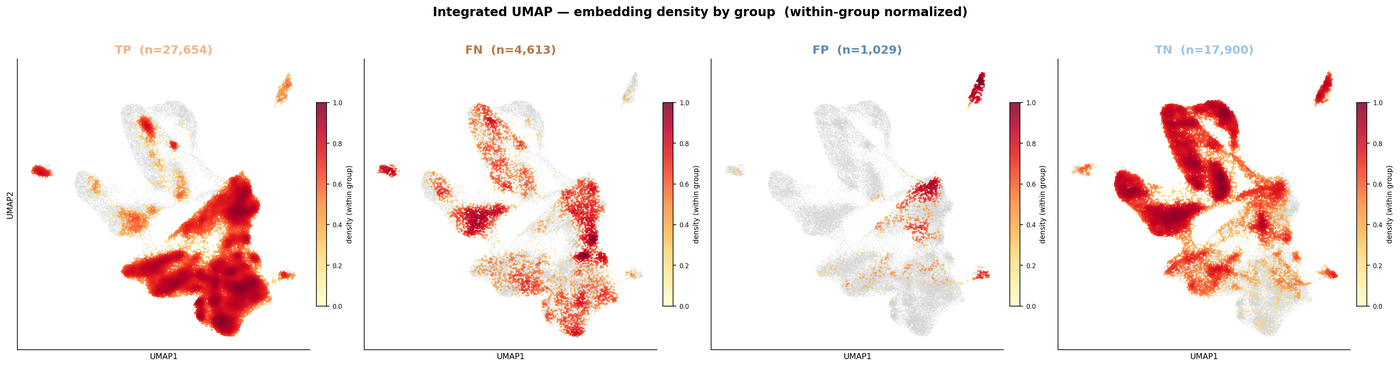

In [ ]:
# 4-group density
Image(str(COMP / "umap_FN_FP_clusters/umap_int_density_4groups.png"))

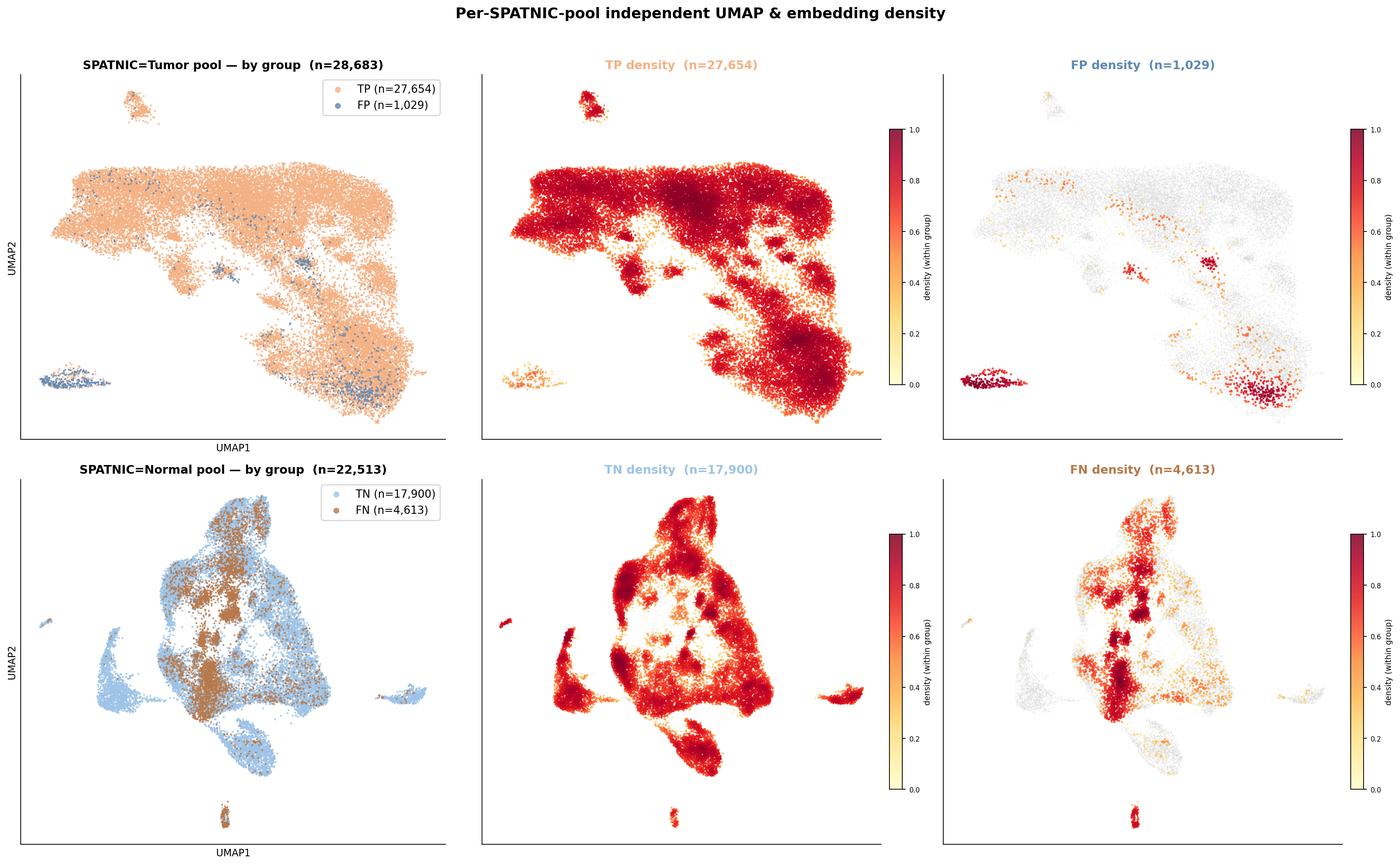

In [ ]:
# Per-pool UMAP density
Image(str(COMP / "umap_FN_FP_clusters/embedding_density_per_pool_umap.png"))

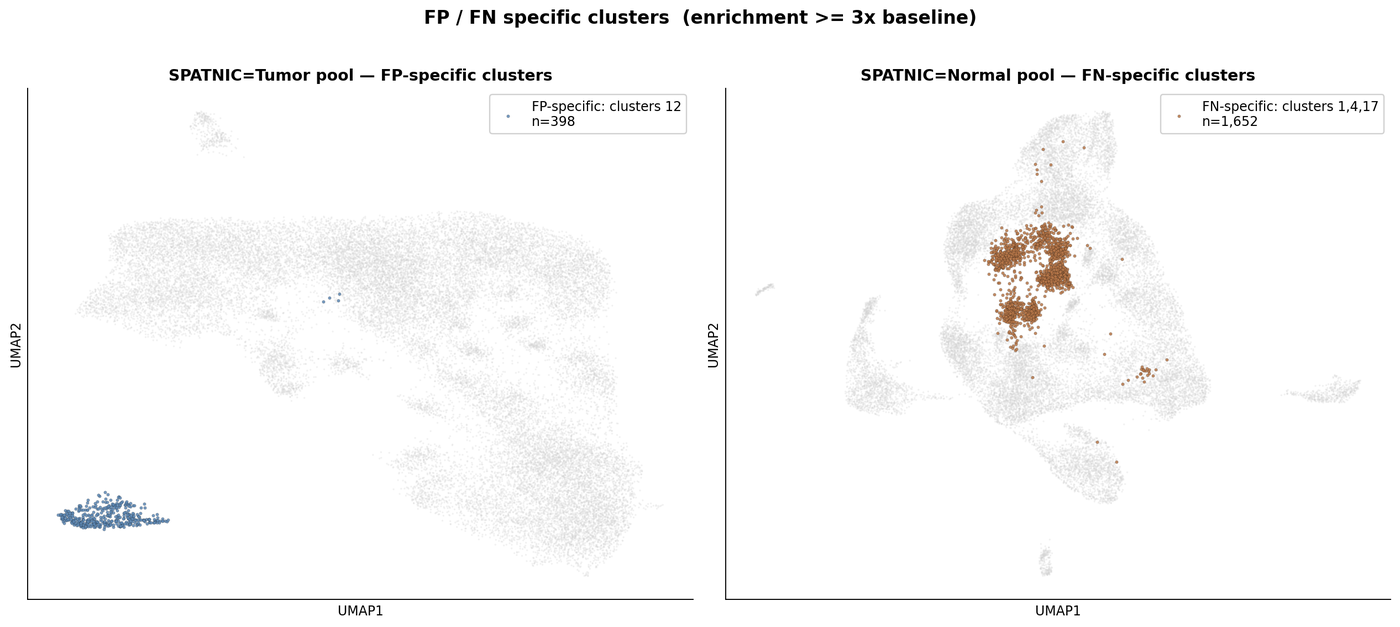

In [ ]:
# FP/FN-specific clusters
Image(str(COMP / "umap_FN_FP_clusters/specific_clusters_per_pool.png"))